### Домашняя работа

**Задание простого уровня** Мы говорили, что метрики качества нужны, чтобы сравнивать различные модели между собой. В задаче полиномиальной регрессии реализуйте код для выбора лучшей степени полиному:

* возьмите все степени от 1 до 10 по порядку, без пропусков.
* найдите степень полинома, где будет лучший r2-score
* напишите код, который выводит самую подходящую степень полинома и соответствующий ей скор

Эта процедура называется Grid Search и помогает найти лучшие параметры для модели.

Обучите лучшую модель и сделайте predict

In [51]:
data = pd.read_csv('non_linear_BzMcVXt.csv', sep=',')
data.head()

,x_train,y_train
0,0.138368,0.838812
1,0.157237,0.889313
2,0.188684,1.430040
3,0.685553,1.717309
4,0.874237,2.032588


In [52]:
#добавляем функцию, которая принимает на вход одномерный массив, а возвращает n-мерный
from sklearn.metrics import mean_squared_error
def generate_degrees(source_data: list, degree: int):
    """Функция, которая принимает на вход одномерный массив, а возвращает n-мерный
    
    Для каждой степени от 1 до  degree возводим x в эту степень
    """
    return np.array([
          source_data**n for n in range(1, degree + 1)  
    ]).T
#добавляем функцию, корорая генерит данные с заданной степенью полинома, обучает модель и выводит степень полинома,значение ошибки
def train_polynomial(degree, data):
    """Генерим данные, тренируем модель
    
    дополнительно рисуем график
    """
    
    X = generate_degrees(data['x_train'], degree)

    model = LinearRegression().fit(X, data['y_train'])
    y_pred = model.predict(X)

    error = mean_squared_error(data['y_train'], y_pred)
    return degree, error

    #plt.scatter(data['x_train'], data['y_train'],  s=40, c='g', marker='o', alpha=0.9, label='data')
    #plt.plot(data['x_train'], y_pred)

In [53]:
#циклом вызываем функцию к степеням полинома от 1 до 10
min_error = 1
min_degree = 0
for x in range(10):
    degree = int(x+1)
    first_value, second_value = train_polynomial(degree, data)
    #print(first_value, second_value)
    if min_error > second_value:        
        min_error = second_value
        min_degree = degree
print(f"Минимальное значение ошибки: {round(min_error,3)}, степень полинома: {min_degree}")
    

Минимальное значение ошибки: 0.058, степень полинома: 10


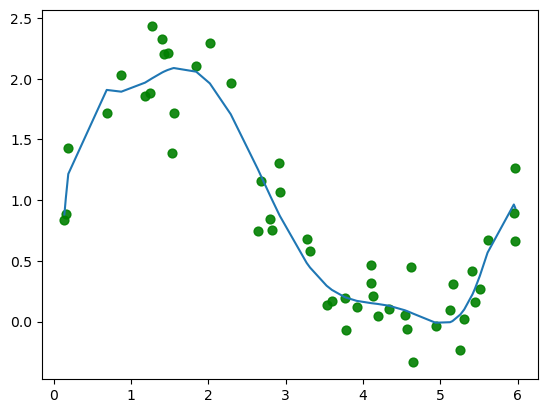

In [54]:
#обучаем лучшую модель и сделаем предсказание. отразим на графике
X = generate_degrees(data['x_train'], min_degree)

model = LinearRegression().fit(X, data['y_train'])
y_pred = model.predict(X)

error = mean_squared_error(data['y_train'], y_pred)
plt.scatter(data['x_train'], data['y_train'],  s=40, c='g', marker='o', alpha=0.9, label='data')
plt.plot(data['x_train'], y_pred)

**Задание среднего уровня** Напишите класс для обучения модели, который содержит:

* функцию `.fit(X, y)` , которая принимает на вход массив фичей `X`, массив таргетов `y` и обучает коэффициенты регрессии. Код для обучения взять из первого урока модуля *Постановка ML задачи линейной регрессии*
* функцию `.predict(X)`, которая по массиву фичей `X` возвращает массив предсказаний `y`

Нужно использовать код для аналитически вычисляемых коэффициентов.

Это задание позволит понять, как работает линейная регрессия "внутри" библиотечной реализации.

In [77]:
class CustomLinearReg:
    def __init__(self):
        self.w0 = None  #intercept
        self.w1 = None  #slope

    def fit(self, X, y):
        #преобразуем в numpy массивы
        X = np.array(X)
        y = np.array(y)
        #добавляем столбец единиц для intercept (w0)
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        
        #для вывода к-ов регрессии сначала перемножаем матрицы
        w_analytic = X_with_intercept.T.dot(X_with_intercept)

        #находим обратную матрицу
        w_analytic_inv = np.linalg.inv(w_analytic)
        #перемножаем матрицы
        w = w_analytic_inv.dot(X_with_intercept.T).dot(y)
        #сохраняем коэффициенты как атрибуты класса
        self.w0 = w[0]
        self.w1 = w[1]
        #выводим результат перемножения - требуемые коэфициэнты
        return self
                

    def predict(self,X):
        #проверяем, что модель обучена
        if self.w0 is None or self.w1 is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit()")
        X = np.array(X)
        #вычисляем предсказания: y_pred = w0 + w1 * X
        y_pred = self.w0 + self.w1 * X

        return y_pred

In [80]:
#проверяем работу функций
#cоздаем и обучаем модель
model = CustomLinearReg()

#пример данных
X_train = data['x_train']
y_train = data['y_train']

#обучаем модель
model.fit(X_train, y_train)

#делаем предсказания
X_test = np.array([0.1, 0.6, 0.9])
predictions = model.predict(X_test)

print(f"Коэффициенты: w0 = {model.w0:.2f}, w1 = {model.w1:.2f}")
print(f"Предсказания: {predictions}")

Коэффициенты: w0 = 1.97, w1 = -0.34
Предсказания: [1.93550393 1.76784657 1.66725215]


**Задание высокого уровня**

1. разделите датасет с домами Бостона из Урока 2 (таргет и фичи) на две части: в одной части 80% датасета (назовём train) в другой 20% (назовём valid) с помощью функции `train_test_split` из библиотеки `sklearn`
1. обучите модель только на train датасете
1. постройте предсказания valid датасете
1. Посчитайте  `r2 score` на валидационном сете

После этого примените к обеим датасетам z-преобразование и повторите шаги 2-4. Как изменилась метрика r2?

Это задание поможет понять, как валидировать линейную регрессию (и другие модели) на отложенной выборке.

In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#загрузка данных
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
raw_df

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8
...,...,...,...,...,...,...,...,...,...,...,...
1007,396.90000,5.64,23.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1008,0.10959,0.00,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0
1009,393.45000,6.48,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1010,0.04741,0.00,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0


In [96]:
#создание матрицы признаков и целевой переменной 
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]]) #объединяем признаки
target = raw_df.values[1::2, 2] #извлекаем целевую переменную


In [100]:
#разделение на обучающую и тестовую выборки
#20% данных пойдут в валидационную выборку
#для воспроизводимости результатов используем функцию train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(data, target, test_size=0.2, random_state=42)

In [134]:
#выясняем количество признаков для обучения
X_train.shape, 
X_valid.shape


(102, 13)

In [111]:
y_train.shape,
y_valid.shape

(102,)

In [120]:
#импортируем модули, отвечающие за линейную регрессию
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [132]:
#обучаем модель на тестовых данных
model = LinearRegression()
model.fit(X_train, y_train) 

#делаем предсказания
y_train_pred = model.predict(X_train)  #предсказания на обучающих данных
y_valid_pred = model.predict(X_valid) 

#ошибки на обучающей выборке
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)

#ошибки на валидационной выборке
valid_mae = mean_absolute_error(y_valid, y_valid_pred)
valid_mse = mean_squared_error(y_valid, y_valid_pred)

#выводим ошибки
print(f"Обучающая выборка:")
print(f"  MAE = {train_mae:.4f}")
print(f"  MSE = {train_mse:.4f}")
print(f"Валидационная выборка:")
print(f"  MAE = {valid_mae:.4f}")
print(f"  MSE = {valid_mse:.4f}")

#строим предсказание на валидном датасете
#создаем функцию предсказания по 13 признакам
def predict_price(features):
    #делаем предсказание на исходных признаках
    prediction = model.predict([features])
    return prediction[0]
    
#использование функции предсказания
use_features = X_valid[0]  #берем первый элемент
predicted_price = predict_price(use_features)
actual_price = y_valid[0]

#выводим результат
print(f"\nПредсказанная цена: {predicted_price:.2f}")
print(f"Фактическая цена: {actual_price:.2f}")
print(f"Ошибка: {abs(predicted_price - actual_price):.2f}")

Обучающая выборка:
  MAE = 3.3148
  MSE = 21.6414
Валидационная выборка:
  MAE = 3.1891
  MSE = 24.2911

Предсказанная цена: 29.00
Фактическая цена: 23.60
Ошибка: 5.40


In [122]:

#применяем z-преобразование к обоим датасетам

#создаем экземпляр объекта
scaler = StandardScaler()

#вычисляем среднее и стандратное отклонение и применяем (x - mean) / std
X_train_scaled = scaler.fit_transform(X_train)

#применяем (x - mean_train) / std_train
X_valid_scaled = scaler.transform(X_valid)


In [125]:
#обучаем модель на преобразованных данных
model = LinearRegression()
model.fit(X_train_scaled, y_train) 

#делаем предсказания
y_train_pred = model.predict(X_train_scaled)  #предсказания на обучающих данных
y_valid_pred = model.predict(X_valid_scaled) 

#ошибки на обучающей выборке
#train_mae = mean_absolute_error(y_train, y_train_pred)
#train_mse = mean_squared_error(y_train, y_train_pred)

#ошибки на валидационной выборке
valid_mae = mean_absolute_error(y_valid, y_valid_pred)
valid_mse = mean_squared_error(y_valid, y_valid_pred)

#выводим ошибки
#print(f"Обучающая выборка:")
#print(f"  MAE = {train_mae:.4f}")
#print(f"  MSE = {train_mse:.4f}")
print(f"Валидационная выборка:")
print(f"  MAE = {valid_mae:.4f}")
print(f"  MSE = {valid_mse:.4f}")

#строим предсказание на валидном датасете
#создаем функцию предсказания по 13 признакам
def predict_price(features):
    #масштабируем признаки
    features_scaled = scaler.transform([features])
    #делаем предсказание
    prediction = model.predict(features_scaled)
    return prediction[0]
#использование функции предсказания
use_features = X_valid[0]  #берем первый элемент
predicted_price = predict_price(use_features)
actual_price = y_valid[0]
#выводим результат
print(f"\nПредсказанная цена: {predicted_price:.2f}")
print(f"Фактическая цена: {actual_price:.2f}")
print(f"Ошибка: {abs(predicted_price - actual_price):.2f}")



Валидационная выборка:
  MAE = 3.1891
  MSE = 24.2911

Предсказанная цена: 29.00
Фактическая цена: 23.60
Ошибка: 5.40


In [ ]:
#Вывод: Результаты одинаковы потому что линейная регрессия в sklearn не чувствительна к масштабированию признаков при использовании аналитического решения